In [39]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [40]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vehicle-dataset-from-cardekho' dataset.
Path to dataset files: /kaggle/input/vehicle-dataset-from-cardekho


In [41]:
# ── Quick EDA ──────────────────────────────────────────────────────────────
import pandas as pd
import os

# List contents of the downloaded directory to find the correct path
print("Contents of the downloaded directory:")
print(os.listdir(path))

dataframe_raw = pd.read_csv(f"{path}/car data.csv")

print("=== Missing Values ===")
print(dataframe_raw.isnull().sum())
print("\n=== Dtypes ===")
print(dataframe_raw.dtypes)
print("\n=== Basic Stats ===")
dataframe_raw.describe()

Contents of the downloaded directory:
['car data.csv', 'car details v4.csv', 'CAR DETAILS FROM CAR DEKHO.csv', 'Car details v3.csv']
=== Missing Values ===
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

=== Dtypes ===
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

=== Basic Stats ===


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [42]:
# ── Feature Engineering ────────────────────────────────────────────────────
CURRENT_YEAR = 2024
dataframe_raw['Car_Age'] = CURRENT_YEAR - dataframe_raw['Year']

dataframe = dataframe_raw.drop(['Car_Name', 'Year'], axis=1)

print("Columns after feature engineering:", list(dataframe.columns))
dataframe.head()

Columns after feature engineering: ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


In [43]:
# ── Encode Categoricals & Define Features

categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']

for col in categorical_cols:
    dataframe[col] = dataframe[col].astype('category').cat.codes
    print(f"{col} → {dict(enumerate(dataframe_raw[col].astype('category').cat.categories))}")

input_cols  = ['Car_Age', 'Present_Price', 'Kms_Driven', 'Owner',
               'Fuel_Type', 'Seller_Type', 'Transmission']
output_cols = ['Selling_Price']

print(f"\nNumber of input features: {len(input_cols)}")

Fuel_Type → {0: 'CNG', 1: 'Diesel', 2: 'Petrol'}
Seller_Type → {0: 'Dealer', 1: 'Individual'}
Transmission → {0: 'Automatic', 1: 'Manual'}

Number of input features: 7


In [44]:
# ── Normalize Features ────────────────────────────────────────────────────

inputs_array  = dataframe[input_cols].to_numpy(dtype=np.float32)
targets_array = dataframe[output_cols].to_numpy(dtype=np.float32)

targets_array = np.log1p(targets_array)

scaler = StandardScaler()
inputs_scaled = scaler.fit_transform(inputs_array)

print("Feature means (after scaling, should be ~0):", inputs_scaled.mean(axis=0).round(3))
print("Feature stds  (after scaling, should be ~1):", inputs_scaled.std(axis=0).round(3))

Feature means (after scaling, should be ~0): [-0.  0. -0.  0. -0. -0. -0.]
Feature stds  (after scaling, should be ~1): [1. 1. 1. 1. 1. 1. 1.]


In [48]:
# ── Build Dataset & DataLoaders ───────────────────────────────────────────
inputs  = torch.tensor(inputs_scaled, dtype=torch.float32)
targets = torch.tensor(targets_array, dtype=torch.float32)

dataset = TensorDataset(inputs, targets)

train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size],
                                generator=torch.Generator().manual_seed(42))
batch_size   = 32
train_loader = DataLoader(train_ds, batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size)

print(f"Train samples: {len(train_ds)} | Val samples: {len(val_ds)}")

Train samples: 240 | Val samples: 61


In [49]:
# ── Improved Model ─────────────────────────────────────────────────────────

input_size  = len(input_cols)
output_size = len(output_cols)

class CarsModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, output_size)
        )

    def forward(self, xb):
        return self.network(xb)

    def training_step(self, batch):
        inputs, targets = batch
        out  = self(inputs)
        loss = F.mse_loss(out, targets)
        return loss

    def validation_step(self, batch):
        inputs, targets = batch
        out  = self(inputs)
        loss = F.mse_loss(out, targets)
        mae  = F.l1_loss(out, targets)
        return {'val_loss': loss.detach(), 'val_mae': mae.detach()}

    def validation_epoch_end(self, outputs):
        losses = torch.stack([x['val_loss'] for x in outputs]).mean()
        maes   = torch.stack([x['val_mae']  for x in outputs]).mean()
        return {'val_loss': losses.item(), 'val_rmse': losses.item()**0.5,
                'val_mae': maes.item()}

    def epoch_end(self, epoch, result, num_epochs):
        if (epoch+1) % 50 == 0 or epoch == num_epochs-1:
            print(f"Epoch [{epoch+1:3d}] | RMSE: {result['val_rmse']:.4f} | MAE: {result['val_mae']:.4f}")

model = CarsModel()
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")

CarsModel(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 2625


In [50]:
# ── Training Functions ────────────────────────────────────────────────────
def evaluate(model, val_loader):
    model.eval()
    with torch.no_grad():
        outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader,
        opt_func=torch.optim.Adam):
    history   = []
    optimizer = opt_func(model.parameters(), lr)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=30, factor=0.5)

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        result = evaluate(model, val_loader)
        scheduler.step(result['val_loss'])
        model.epoch_end(epoch, result, epochs)
        history.append(result)
    return history

print("Before training:", evaluate(model, val_loader))

Before training: {'val_loss': 2.496811866760254, 'val_rmse': 1.5801303322068891, 'val_mae': 1.376765251159668}


In [51]:
# ── Train!
history = fit(800, lr=1e-3, model=model,
              train_loader=train_loader, val_loader=val_loader)

Epoch [ 50] | RMSE: 0.3283 | MAE: 0.2185
Epoch [100] | RMSE: 0.3103 | MAE: 0.2055
Epoch [150] | RMSE: 0.2990 | MAE: 0.2098
Epoch [200] | RMSE: 0.2916 | MAE: 0.1924
Epoch [250] | RMSE: 0.2852 | MAE: 0.1957
Epoch [300] | RMSE: 0.2832 | MAE: 0.1890
Epoch [350] | RMSE: 0.2803 | MAE: 0.1874
Epoch [400] | RMSE: 0.2778 | MAE: 0.1874
Epoch [450] | RMSE: 0.2794 | MAE: 0.1865
Epoch [500] | RMSE: 0.2791 | MAE: 0.1858
Epoch [550] | RMSE: 0.2790 | MAE: 0.1856
Epoch [600] | RMSE: 0.2791 | MAE: 0.1856
Epoch [650] | RMSE: 0.2791 | MAE: 0.1856
Epoch [700] | RMSE: 0.2791 | MAE: 0.1855
Epoch [750] | RMSE: 0.2791 | MAE: 0.1855
Epoch [800] | RMSE: 0.2791 | MAE: 0.1855


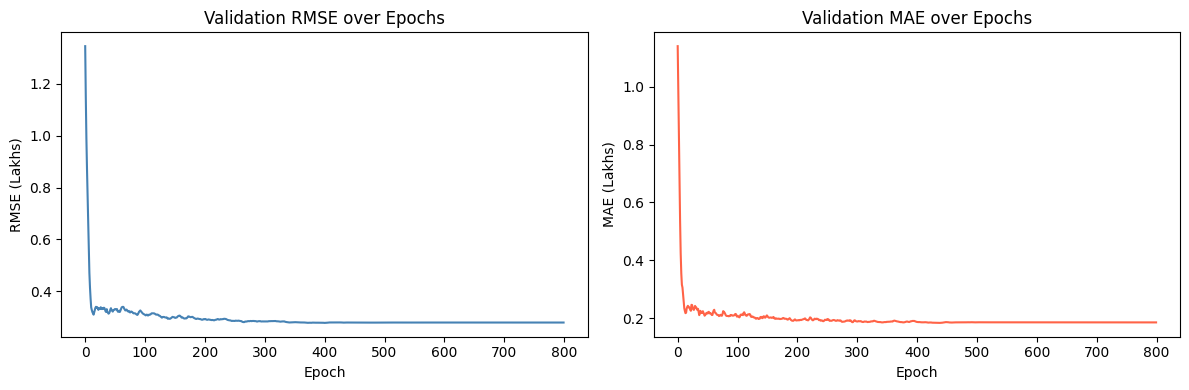

In [52]:
# ── Plot Training Curve ───────────────────────────────────────────────────
rmse_vals = [h['val_rmse'] for h in history]
mae_vals  = [h['val_mae']  for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rmse_vals, color='steelblue')
axes[0].set_title('Validation RMSE over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('RMSE (Lakhs)')
axes[1].plot(mae_vals, color='tomato')
axes[1].set_title('Validation MAE over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (Lakhs)')
plt.tight_layout()
plt.savefig('training_curve.png', dpi=120)
plt.show()

In [53]:
# ── Evaluate on Full Validation Set ──────────────────────────────────────
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for inputs, targets in val_loader:
        preds = model(inputs)
        all_preds.append(preds)
        all_targets.append(targets)

all_preds   = np.expm1(torch.cat(all_preds).numpy().flatten())
all_targets = np.expm1(torch.cat(all_targets).numpy().flatten())

mae  = np.mean(np.abs(all_preds - all_targets))
rmse = np.sqrt(np.mean((all_preds - all_targets)**2))
r2   = r2_score(all_targets, all_preds)

print(f"{'='*40}")
print(f"  Final Validation Metrics")
print(f"{'='*40}")
print(f"  MAE  : {mae:.4f} Lakhs")
print(f"  RMSE : {rmse:.4f} Lakhs")
print(f"  R²   : {r2:.4f}  (1.0 = perfect)")
print(f"{'='*40}")

  Final Validation Metrics
  MAE  : 0.8089 Lakhs
  RMSE : 1.2588 Lakhs
  R²   : 0.9087  (1.0 = perfect)


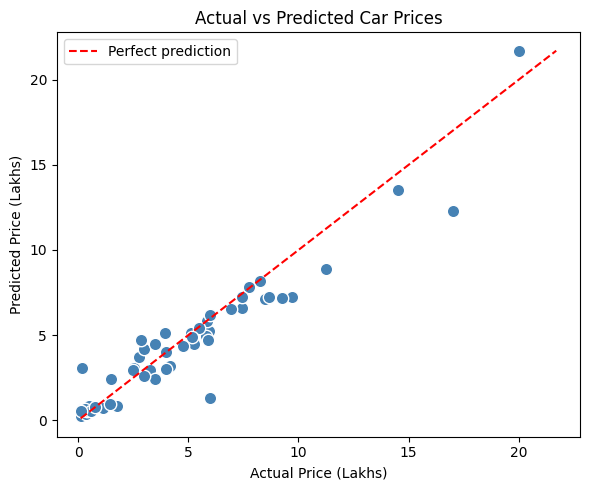

In [54]:
# ── Predict vs Actual Plot ────────────────────────────────────────────────
plt.figure(figsize=(6, 5))
plt.scatter(all_targets, all_preds, color='steelblue', edgecolors='white', s=80)
mn, mx = min(all_targets.min(), all_preds.min()), max(all_targets.max(), all_preds.max())
plt.plot([mn, mx], [mn, mx], 'r--', label='Perfect prediction')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Actual vs Predicted Car Prices')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=120)
plt.show()

In [55]:
# ── Single Prediction ─────────────────────────────────────────────────────
def predict_single(index, val_ds, model):
    input_tensor, target = val_ds[index]
    model.eval()
    with torch.no_grad():
        pred = model(input_tensor.unsqueeze(0))[0].item()

        actual = np.expm1(target.item())
    predicted = np.expm1(pred)

    print(f"Actual Price : {actual:.4f} Lakhs")
    print(f"Predicted    : {predicted:.4f} Lakhs")
    print(f"Error        : {abs(predicted - actual):.4f} Lakhs")

for i in range(len(val_ds)):
    print(f"--- Sample {i} ---")
    predict_single(i, val_ds, model)

--- Sample 0 ---
Actual Price : 1.3500 Lakhs
Predicted    : 0.9362 Lakhs
Error        : 0.4138 Lakhs
--- Sample 1 ---
Actual Price : 7.4500 Lakhs
Predicted    : 6.6199 Lakhs
Error        : 0.8301 Lakhs
--- Sample 2 ---
Actual Price : 9.7000 Lakhs
Predicted    : 7.2651 Lakhs
Error        : 2.4349 Lakhs
--- Sample 3 ---
Actual Price : 19.9900 Lakhs
Predicted    : 21.6915 Lakhs
Error        : 1.7015 Lakhs
--- Sample 4 ---
Actual Price : 4.0000 Lakhs
Predicted    : 4.0026 Lakhs
Error        : 0.0026 Lakhs
--- Sample 5 ---
Actual Price : 8.2500 Lakhs
Predicted    : 8.1857 Lakhs
Error        : 0.0643 Lakhs
--- Sample 6 ---
Actual Price : 0.1700 Lakhs
Predicted    : 3.0914 Lakhs
Error        : 2.9214 Lakhs
--- Sample 7 ---
Actual Price : 3.2500 Lakhs
Predicted    : 2.9778 Lakhs
Error        : 0.2722 Lakhs
--- Sample 8 ---
Actual Price : 1.5000 Lakhs
Predicted    : 2.4118 Lakhs
Error        : 0.9118 Lakhs
--- Sample 9 ---
Actual Price : 5.7500 Lakhs
Predicted    : 5.4399 Lakhs
Error        : 0

In [56]:
!pip install gradio

In [59]:
import gradio as gr

def predict_price(car_age, present_price, kms_driven, owner, fuel_type, seller_type, transmission):
    # Encode categoricals the same way as training
    fuel_map        = {'CNG': 0, 'Diesel': 1, 'Petrol': 2}
    seller_map      = {'Dealer': 0, 'Individual': 1}
    transmission_map = {'Automatic': 0, 'Manual': 1}

    # Build input array
    input_data = np.array([[
        car_age,
        present_price,
        kms_driven,
        owner,
        fuel_map[fuel_type],
        seller_map[seller_type],
        transmission_map[transmission]
    ]], dtype=np.float32)

    # Scale using the same scaler from training
    input_scaled = scaler.transform(input_data)
    input_tensor = torch.tensor(input_scaled, dtype=torch.float32)

    # Predict and reverse log-transform
    model.eval()
    with torch.no_grad():
        log_pred = model(input_tensor)[0].item()

    price = np.expm1(log_pred)
    return f"🚗 Estimated Selling Price: ₹ {price:.2f} Lakhs"


# Build the interface
demo = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Slider(1, 20, value=5, step=1,        label="Car Age (years)"),
        gr.Slider(1, 50, value=8.0, step=0.1,    label="Present Price (Lakhs)"),
        gr.Slider(0, 200000, value=30000, step=500, label="Kms Driven"),
        gr.Slider(0, 3, value=0, step=1,          label="Number of Previous Owners"),
        gr.Dropdown(['Petrol', 'Diesel', 'CNG'],  label="Fuel Type"),
        gr.Dropdown(['Dealer', 'Individual'],      label="Seller Type"),
        gr.Dropdown(['Manual', 'Automatic'],       label="Transmission"),
    ],
    outputs=gr.Textbox(label="Predicted Price"),
    title="🚗 Car Price Predictor",
    description="Enter the car details below to predict its selling price in Lakhs (₹)",
)

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b961e4d8883219623a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [60]:
torch.save(model.state_dict(), 'car_model.pth')  # save
model.load_state_dict(torch.load('car_model.pth'))  # load

<All keys matched successfully>